In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('hotel_bookings.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print("Shape:", df.shape)
print("\n--- Column Names ---")
print(df.columns.tolist())
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n--- Duplicates ---")
print("Duplicate rows:", df.duplicated().sum())

Shape: (119390, 32)

--- Column Names ---
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

--- Data Types ---
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights  

In [4]:
# 1. Drop duplicates
df.drop_duplicates(inplace=True)

# 2. Fix missing values
df['children'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

# 3. Remove invalid ADR rows
df = df[df['adr'] >= 0]
df = df[df['adr'] < 5000]

# 4. Create derived features
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# 5. Non-cancelled bookings only dataset
df_clean = df[df['is_canceled'] == 0].copy()

print("✅ Cleaning done!")
print("Total rows after cleaning:", len(df))
print("Non-cancelled bookings:", len(df_clean))

✅ Cleaning done!
Total rows after cleaning: 87394
Non-cancelled bookings: 63370


Top 10 Guest Countries:
  country  guests
0     PRT   17662
1     GBR    8447
2     FRA    7104
3     ESP    5390
4     DEU    4334
5     IRL    2348
6     ITA    1991
7     BEL    1670
8     NLD    1561
9     USA    1416


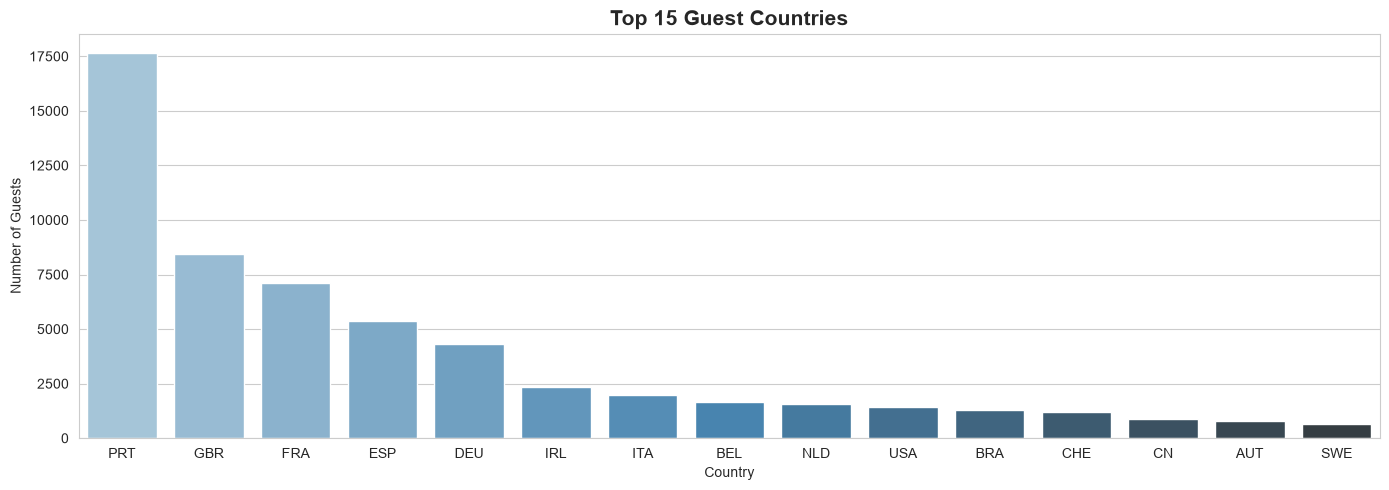

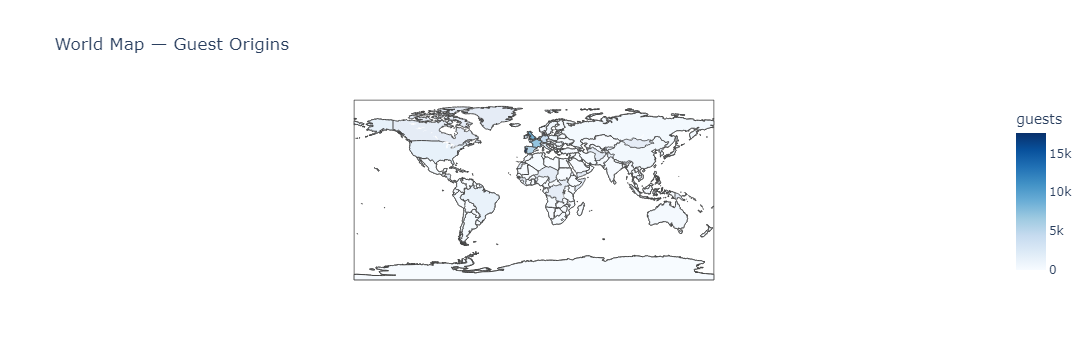


✅ INSIGHT:
Portugal (PRT) has the highest number of guests.
Most guests come from European countries.


In [5]:
# Top 10 countries table
country_data = df_clean['country'].value_counts().reset_index()
country_data.columns = ['country', 'guests']
print("Top 10 Guest Countries:")
print(country_data.head(10))

# Bar chart - Top 15 countries
plt.figure(figsize=(14, 5))
sns.barplot(data=country_data.head(15), x='country', y='guests', palette='Blues_d')
plt.title('Top 15 Guest Countries', fontsize=15, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Guests')
plt.tight_layout()
plt.show()

# World Map choropleth
fig = px.choropleth(
    country_data,
    locations='country',
    color='guests',
    hover_name='country',
    color_continuous_scale='Blues',
    title='World Map — Guest Origins'
)
fig.show()

# Insight
print("\n✅ INSIGHT:")
print("Portugal (PRT) has the highest number of guests.")
print("Most guests come from European countries.")

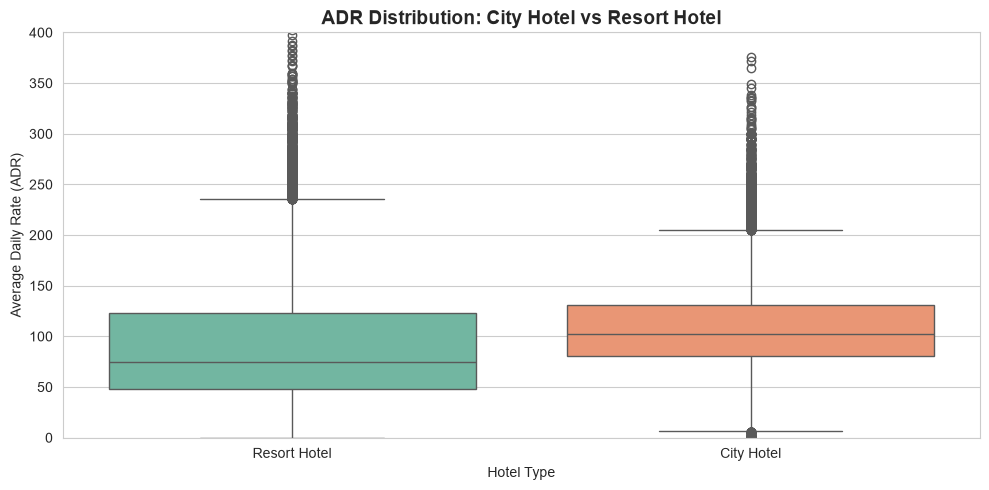

Average ADR by Hotel Type:
hotel
City Hotel      108.28
Resort Hotel     92.97
Name: adr, dtype: float64


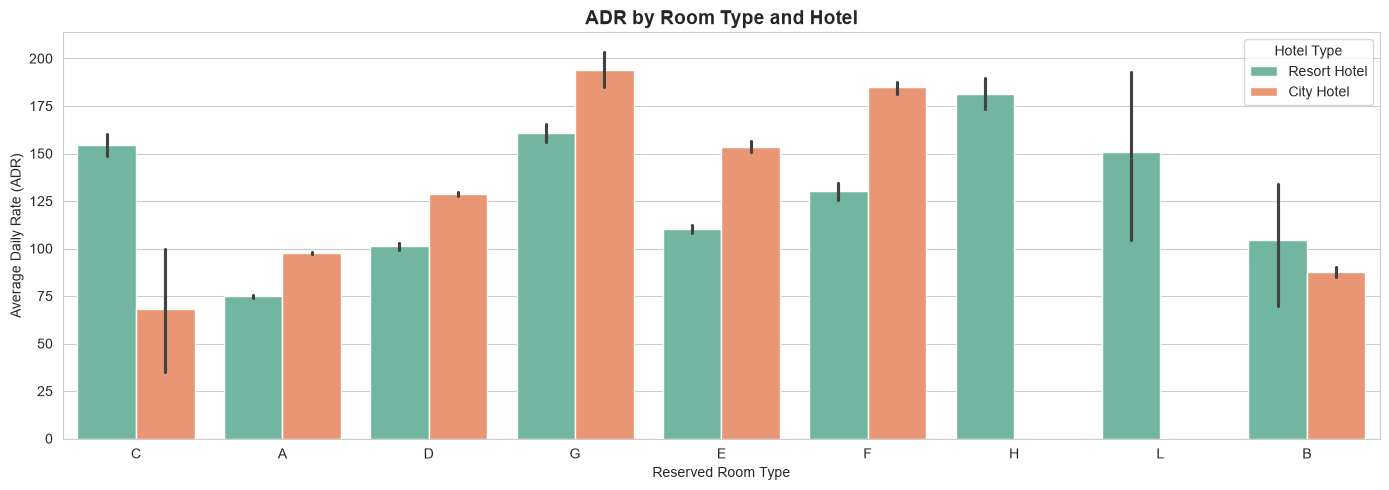


✅ INSIGHT:
City Hotel has higher average ADR than Resort Hotel.
Room type H and G command the highest prices.


In [6]:
# 1. Average ADR - City vs Resort
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='hotel', y='adr', palette='Set2')
plt.title('ADR Distribution: City Hotel vs Resort Hotel', fontsize=14, fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.ylim(0, 400)
plt.tight_layout()
plt.show()

# 2. Average ADR comparison
adr_hotel = df_clean.groupby('hotel')['adr'].mean().round(2)
print("Average ADR by Hotel Type:")
print(adr_hotel)

# 3. ADR by Room Type and Hotel
plt.figure(figsize=(14, 5))
sns.barplot(data=df_clean, x='reserved_room_type', 
            y='adr', hue='hotel', palette='Set2')
plt.title('ADR by Room Type and Hotel', fontsize=14, fontweight='bold')
plt.xlabel('Reserved Room Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

print("\n✅ INSIGHT:")
print("City Hotel has higher average ADR than Resort Hotel.")
print("Room type H and G command the highest prices.")

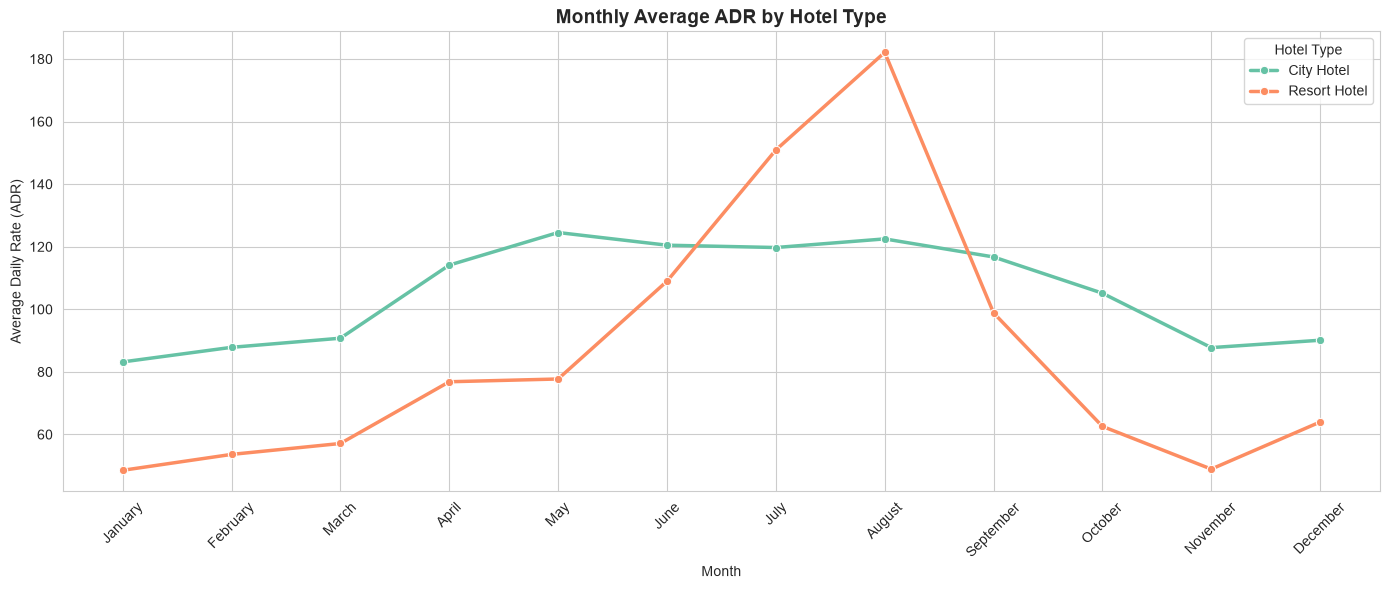


✅ INSIGHT:
Resort Hotel prices peak in Summer (July-August).
City Hotel prices are more stable throughout the year.
August is the most expensive month overall.


In [7]:
# Correct month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Monthly average ADR per hotel
monthly_adr = df_clean.groupby(
    ['arrival_date_month', 'hotel'])['adr'].mean().reset_index()
monthly_adr['arrival_date_month'] = pd.Categorical(
    monthly_adr['arrival_date_month'], categories=month_order, ordered=True)
monthly_adr = monthly_adr.sort_values('arrival_date_month')

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_adr, x='arrival_date_month', 
             y='adr', hue='hotel', marker='o', linewidth=2.5)
plt.title('Monthly Average ADR by Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

print("\n✅ INSIGHT:")
print("Resort Hotel prices peak in Summer (July-August).")
print("City Hotel prices are more stable throughout the year.")
print("August is the most expensive month overall.")

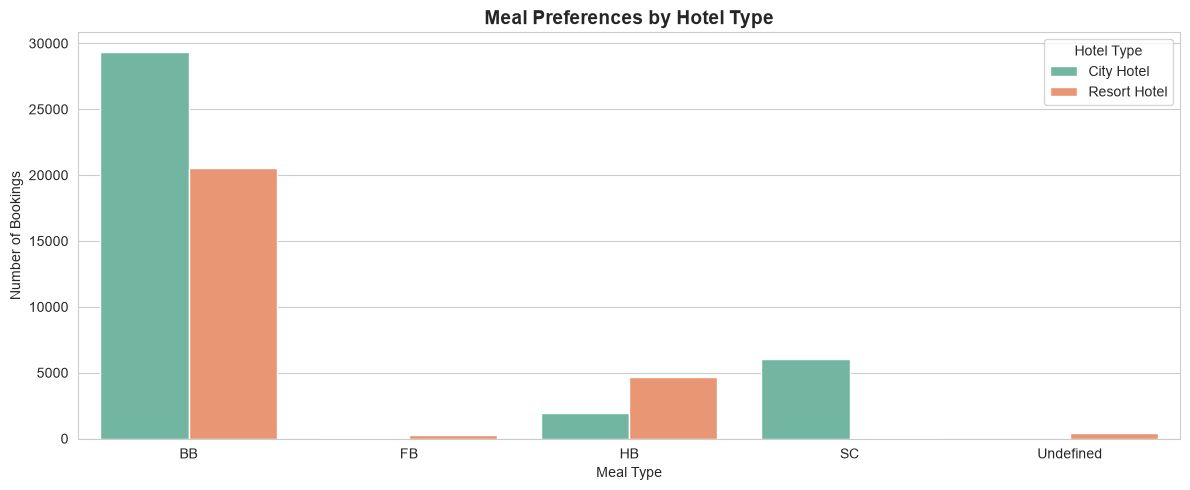

Meal Distribution by Hotel (%):
hotel         meal     
City Hotel    BB           78.5
              SC           16.2
              HB            5.2
              FB            0.0
Resort Hotel  BB           79.2
              HB           18.0
              Undefined     1.6
              FB            1.0
              SC            0.3
Name: proportion, dtype: float64

✅ INSIGHT:
BB (Bed & Breakfast) is the most popular meal plan in both hotels.
Resort Hotel has more HB (Half Board) guests than City Hotel.


In [8]:
# Meal counts by hotel
meal_data = df_clean.groupby(
    ['hotel', 'meal']).size().reset_index(name='count')

plt.figure(figsize=(12, 5))
sns.barplot(data=meal_data, x='meal', 
            y='count', hue='hotel', palette='Set2')
plt.title('Meal Preferences by Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

# Percentage breakdown
print("Meal Distribution by Hotel (%):")
meal_pct = df_clean.groupby('hotel')['meal'].value_counts(
    normalize=True).mul(100).round(1)
print(meal_pct)

print("\n✅ INSIGHT:")
print("BB (Bed & Breakfast) is the most popular meal plan in both hotels.")
print("Resort Hotel has more HB (Half Board) guests than City Hotel.")

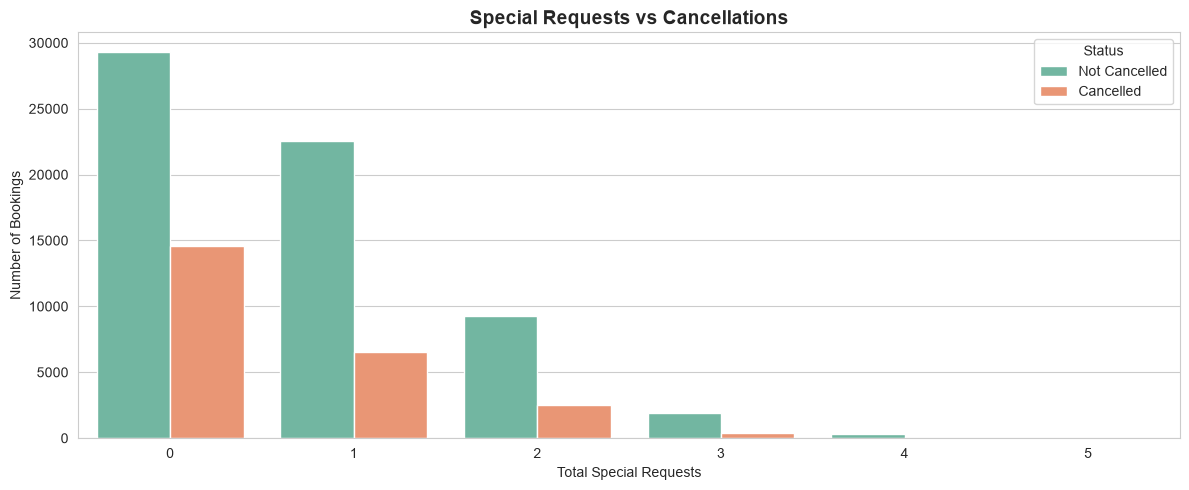

Cancellation Rate by Special Requests:
total_of_special_requests
0    33.2
1    22.4
2    21.3
3    17.1
4    10.6
5     5.6
Name: is_canceled, dtype: float64

✅ INSIGHT:
Guests with 0 special requests cancel the most.
Higher special requests = lower cancellation rate.
Guests who make requests are more committed to their booking.


In [9]:
# Pivot table
special_cancel = df.groupby(
    ['total_of_special_requests', 'is_canceled']).size().reset_index(name='count')
special_cancel['is_canceled'] = special_cancel['is_canceled'].map(
    {0: 'Not Cancelled', 1: 'Cancelled'})

plt.figure(figsize=(12, 5))
sns.barplot(data=special_cancel, x='total_of_special_requests',
            y='count', hue='is_canceled', palette='Set2')
plt.title('Special Requests vs Cancellations', fontsize=14, fontweight='bold')
plt.xlabel('Total Special Requests')
plt.ylabel('Number of Bookings')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

# Cancellation rate by special requests
cancel_rate = df.groupby('total_of_special_requests')['is_canceled'].mean().mul(100).round(1)
print("Cancellation Rate by Special Requests:")
print(cancel_rate)

print("\n✅ INSIGHT:")
print("Guests with 0 special requests cancel the most.")
print("Higher special requests = lower cancellation rate.")
print("Guests who make requests are more committed to their booking.")

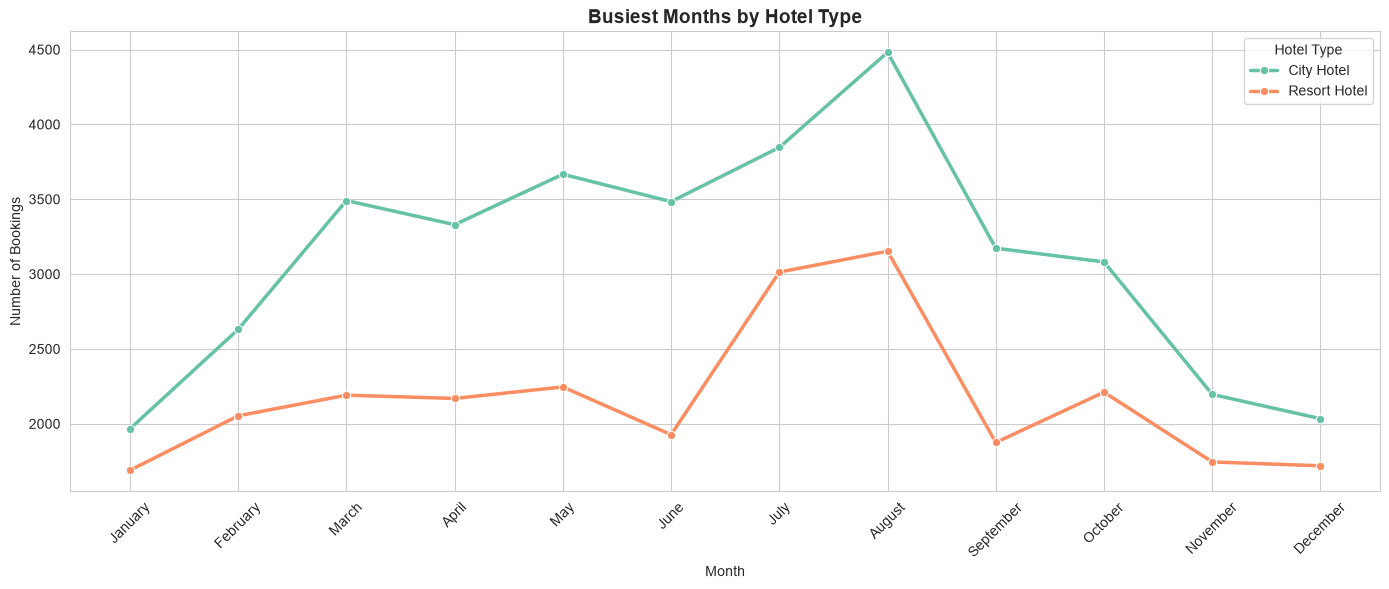


Busiest Month Overall: August - City Hotel

✅ INSIGHT:
August is the busiest month for both hotels.
Resort Hotel peaks sharply in summer months.
City Hotel stays busy from April to October.


In [10]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Guest volume by month and hotel
monthly_guests = df_clean.groupby(
    ['arrival_date_month', 'hotel']).size().reset_index(name='bookings')
monthly_guests['arrival_date_month'] = pd.Categorical(
    monthly_guests['arrival_date_month'], 
    categories=month_order, ordered=True)
monthly_guests = monthly_guests.sort_values('arrival_date_month')

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_guests, x='arrival_date_month',
             y='bookings', hue='hotel', marker='o', linewidth=2.5)
plt.title('Busiest Months by Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

# Find busiest month
busiest = monthly_guests.loc[monthly_guests['bookings'].idxmax()]
print(f"\nBusiest Month Overall: {busiest['arrival_date_month']} - {busiest['hotel']}")

print("\n✅ INSIGHT:")
print("August is the busiest month for both hotels.")
print("Resort Hotel peaks sharply in summer months.")
print("City Hotel stays busy from April to October.")

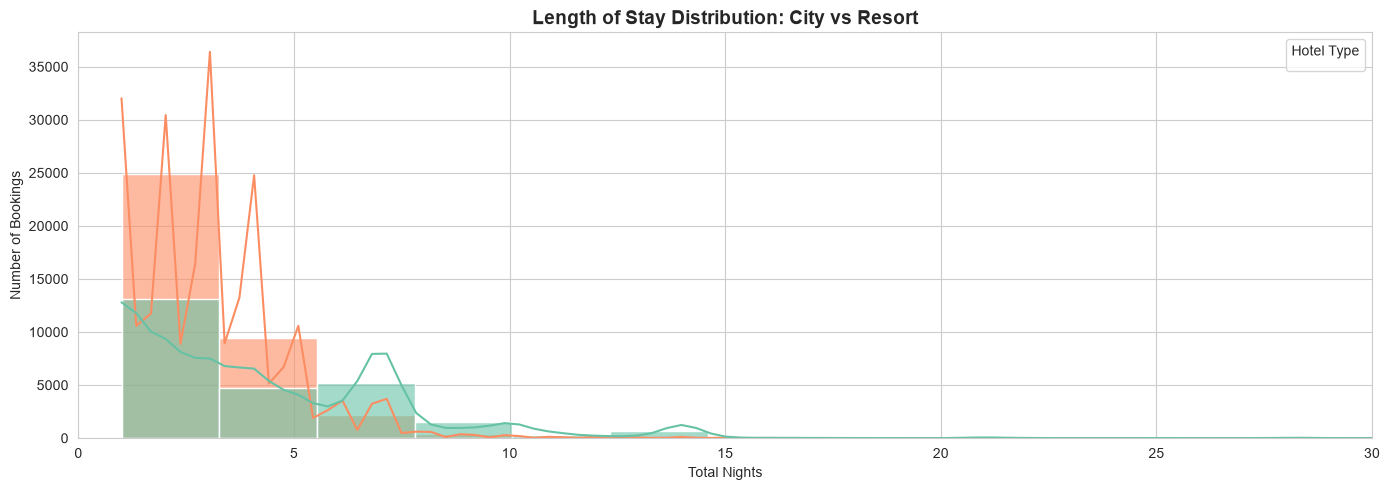

Average Length of Stay:
hotel
City Hotel      3.01
Resort Hotel    4.26
Name: total_nights, dtype: float64

Median Length of Stay:
hotel
City Hotel      3.0
Resort Hotel    3.0
Name: total_nights, dtype: float64

✅ INSIGHT:
Resort Hotel guests stay longer than City Hotel guests.
City Hotel average stay is shorter — mostly business travelers.
Most guests stay between 1-5 nights.


In [11]:
# Remove zero night stays
df_stay = df_clean[df_clean['total_nights'] > 0]

plt.figure(figsize=(14, 5))
sns.histplot(data=df_stay, x='total_nights', hue='hotel',
             bins=30, kde=True, palette='Set2', alpha=0.6)
plt.title('Length of Stay Distribution: City vs Resort', 
          fontsize=14, fontweight='bold')
plt.xlabel('Total Nights')
plt.ylabel('Number of Bookings')
plt.xlim(0, 30)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

# Average stay
avg_stay = df_stay.groupby('hotel')['total_nights'].mean().round(2)
print("Average Length of Stay:")
print(avg_stay)

# Median stay
med_stay = df_stay.groupby('hotel')['total_nights'].median()
print("\nMedian Length of Stay:")
print(med_stay)

print("\n✅ INSIGHT:")
print("Resort Hotel guests stay longer than City Hotel guests.")
print("City Hotel average stay is shorter — mostly business travelers.")
print("Most guests stay between 1-5 nights.")

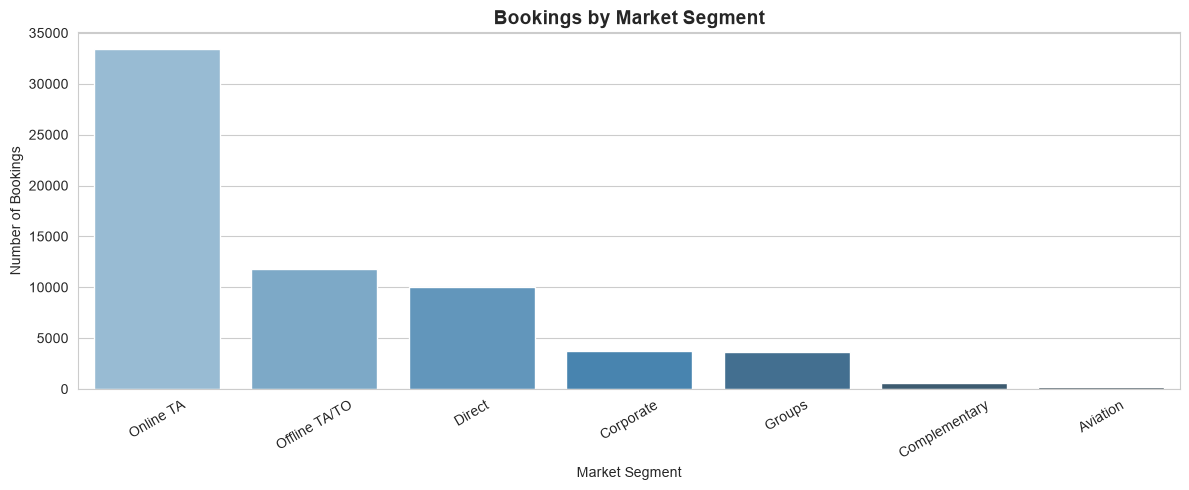

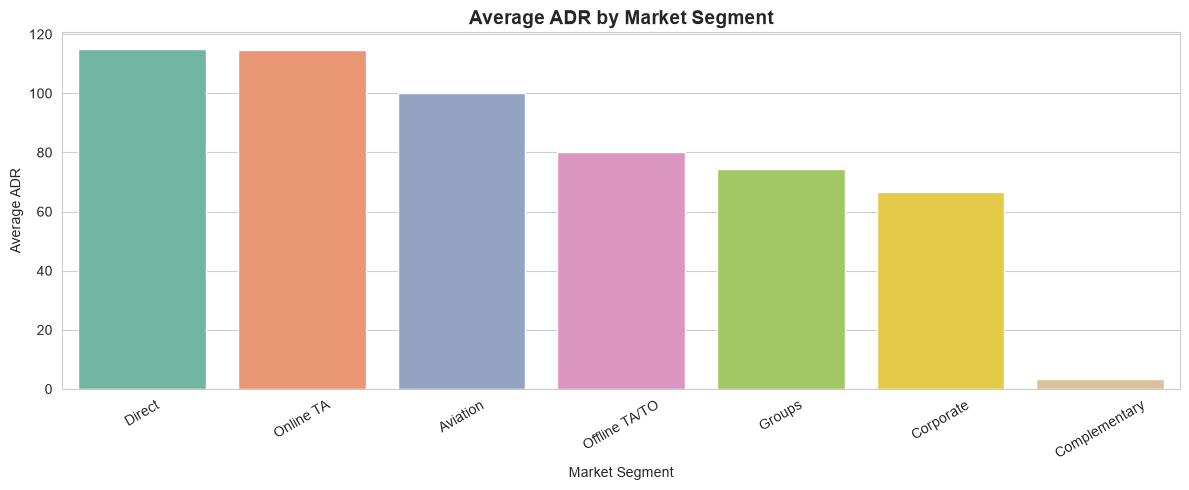

Bookings by Market Segment:
         segment  bookings
0      Online TA     33373
1  Offline TA/TO     11826
2         Direct     10067
3      Corporate      3702
4         Groups      3606
5  Complementary       614
6       Aviation       182

✅ INSIGHT:
Online Travel Agents (OTA) bring the most bookings.
Direct bookings have higher ADR than OTA bookings.
Groups segment has the lowest ADR.


In [12]:
# Bookings by market segment
market_data = df_clean['market_segment'].value_counts().reset_index()
market_data.columns = ['segment', 'bookings']

plt.figure(figsize=(12, 5))
sns.barplot(data=market_data, x='segment', 
            y='bookings', palette='Blues_d')
plt.title('Bookings by Market Segment', fontsize=14, fontweight='bold')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ADR by market segment
plt.figure(figsize=(12, 5))
adr_segment = df_clean.groupby('market_segment')['adr'].mean().sort_values(
    ascending=False).reset_index()
sns.barplot(data=adr_segment, x='market_segment', 
            y='adr', palette='Set2')
plt.title('Average ADR by Market Segment', fontsize=14, fontweight='bold')
plt.xlabel('Market Segment')
plt.ylabel('Average ADR')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Bookings by Market Segment:")
print(market_data)

print("\n✅ INSIGHT:")
print("Online Travel Agents (OTA) bring the most bookings.")
print("Direct bookings have higher ADR than OTA bookings.")
print("Groups segment has the lowest ADR.")

Total Bookings: 87394
Cancelled: 24024
Cancellation Rate: 27.49%


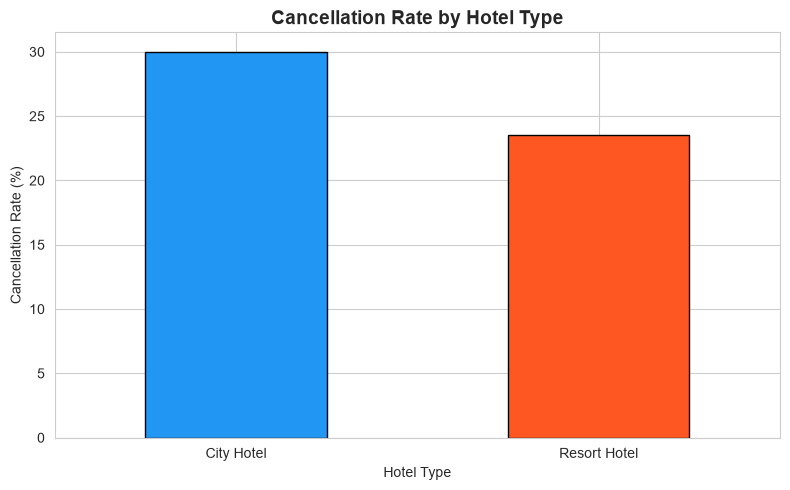


Cancellation Rate by Hotel:
hotel
City Hotel      30.0
Resort Hotel    23.5
Name: is_canceled, dtype: float64


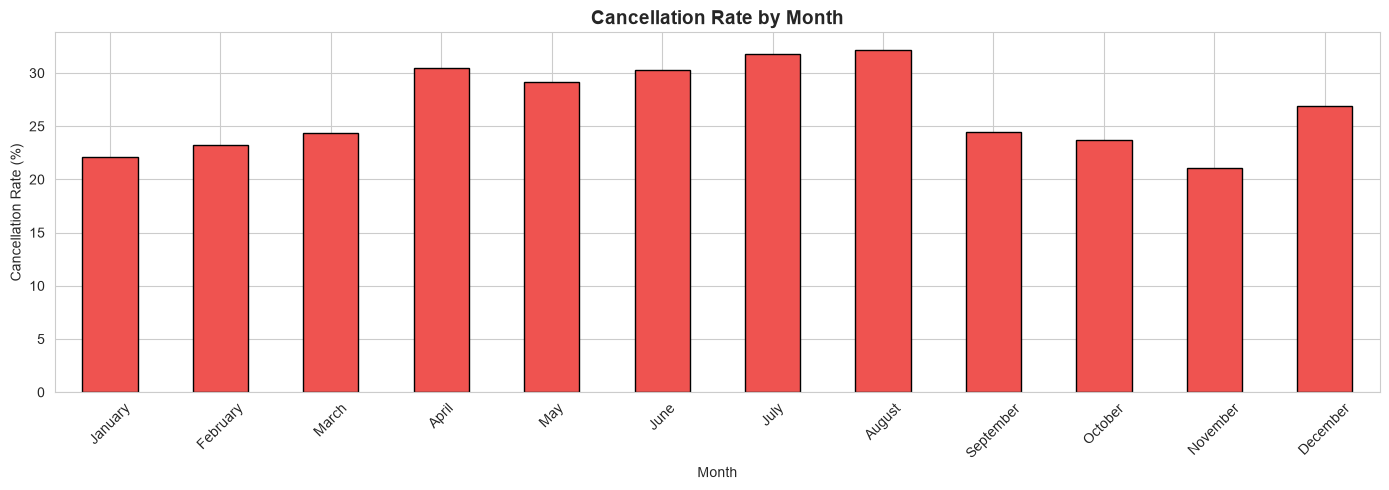


Cancellation Rate by Month:
arrival_date_month
January      22.1
February     23.2
March        24.4
April        30.5
May          29.2
June         30.3
July         31.8
August       32.2
September    24.5
October      23.7
November     21.1
December     26.9
Name: is_canceled, dtype: float64

✅ INSIGHT:
City Hotel has much higher cancellation rate than Resort Hotel.
January and November have highest cancellation rates.
Summer months have lower cancellations despite high bookings.


In [13]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Overall cancellation rate
total        = len(df)
cancelled    = df['is_canceled'].sum()
cancel_rate  = round(cancelled / total * 100, 2)
print(f"Total Bookings: {total}")
print(f"Cancelled: {cancelled}")
print(f"Cancellation Rate: {cancel_rate}%")

# Cancellation by hotel
plt.figure(figsize=(8, 5))
cancel_hotel = df.groupby('hotel')['is_canceled'].mean().mul(100).round(1)
cancel_hotel.plot(kind='bar', color=['#2196F3','#FF5722'], 
                  edgecolor='black')
plt.title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("\nCancellation Rate by Hotel:")
print(cancel_hotel)

# Cancellation by month
cancel_month = df.groupby('arrival_date_month')['is_canceled'].mean().mul(100).round(1)
cancel_month.index = pd.CategoricalIndex(
    cancel_month.index, categories=month_order, ordered=True)
cancel_month = cancel_month.sort_index()

plt.figure(figsize=(14, 5))
cancel_month.plot(kind='bar', color='#EF5350', edgecolor='black')
plt.title('Cancellation Rate by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nCancellation Rate by Month:")
print(cancel_month)

print("\n✅ INSIGHT:")
print("City Hotel has much higher cancellation rate than Resort Hotel.")
print("January and November have highest cancellation rates.")
print("Summer months have lower cancellations despite high bookings.")

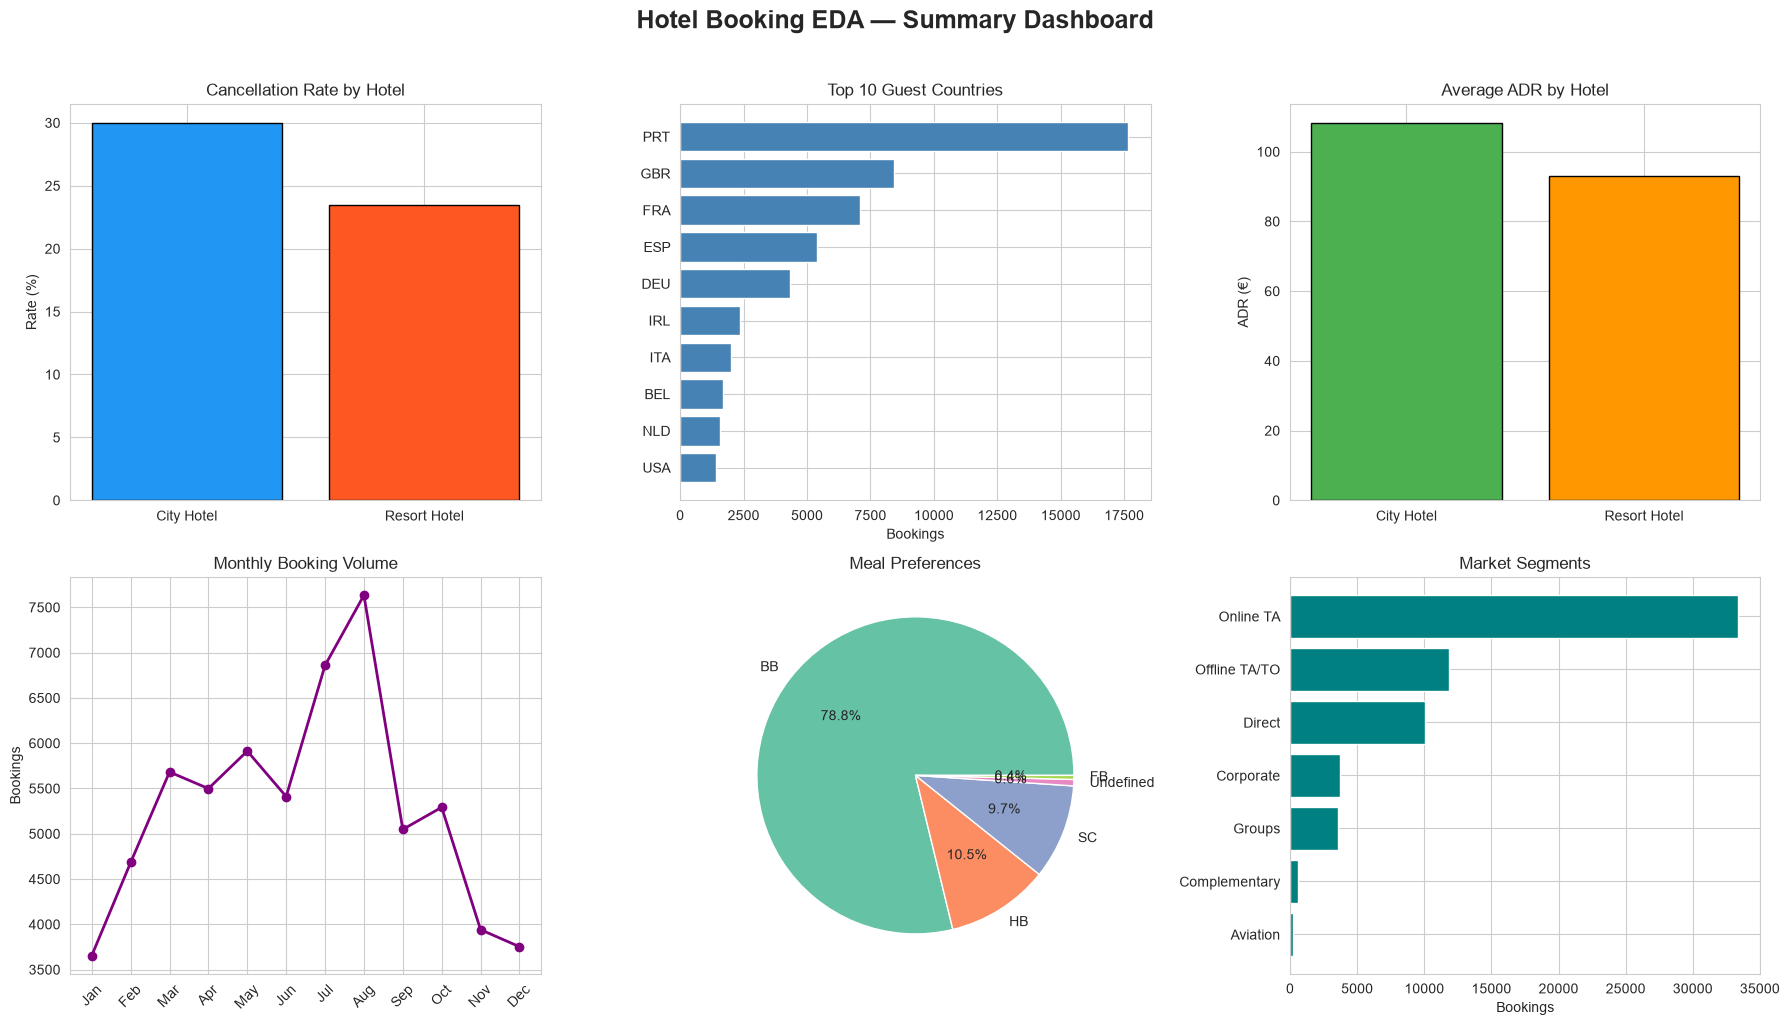

✅ Dashboard saved as hotel_eda_dashboard.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hotel Booking EDA — Summary Dashboard', 
             fontsize=18, fontweight='bold', y=1.02)

# 1. Cancellation Rate by Hotel
cancel_hotel = df.groupby('hotel')['is_canceled'].mean().mul(100).round(1)
axes[0,0].bar(cancel_hotel.index, cancel_hotel.values, 
              color=['#2196F3','#FF5722'], edgecolor='black')
axes[0,0].set_title('Cancellation Rate by Hotel')
axes[0,0].set_ylabel('Rate (%)')

# 2. Top 10 Countries
country_data = df_clean['country'].value_counts().head(10)
axes[0,1].barh(country_data.index[::-1], country_data.values[::-1], 
               color='steelblue')
axes[0,1].set_title('Top 10 Guest Countries')
axes[0,1].set_xlabel('Bookings')

# 3. ADR by Hotel
adr_hotel = df_clean.groupby('hotel')['adr'].mean().round(2)
axes[0,2].bar(adr_hotel.index, adr_hotel.values, 
              color=['#4CAF50','#FF9800'], edgecolor='black')
axes[0,2].set_title('Average ADR by Hotel')
axes[0,2].set_ylabel('ADR (€)')

# 4. Monthly Bookings
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df_clean['arrival_date_month'].value_counts()
monthly.index = pd.CategoricalIndex(
    monthly.index, categories=month_order, ordered=True)
monthly = monthly.sort_index()
axes[1,0].plot(range(12), monthly.values, marker='o', 
               color='purple', linewidth=2)
axes[1,0].set_xticks(range(12))
axes[1,0].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[1,0].set_title('Monthly Booking Volume')
axes[1,0].set_ylabel('Bookings')

# 5. Meal Preferences
meal_data = df_clean['meal'].value_counts()
axes[1,1].pie(meal_data.values, labels=meal_data.index, 
              autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1,1].set_title('Meal Preferences')

# 6. Market Segment
market = df_clean['market_segment'].value_counts()
axes[1,2].barh(market.index[::-1], market.values[::-1], 
               color='teal')
axes[1,2].set_title('Market Segments')
axes[1,2].set_xlabel('Bookings')

plt.tight_layout()
plt.savefig('hotel_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as hotel_eda_dashboard.png")

In [15]:
print("""
╔══════════════════════════════════════════════════════════╗
║         HOTEL BOOKING EDA — KEY INSIGHTS                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Portugal is the top guest origin country (17,662)   ║
║                                                          ║
║  2. City Hotel ADR (€108) > Resort Hotel ADR (€93)      ║
║                                                          ║
║  3. August is busiest AND highest cancellation month     ║
║                                                          ║
║  4. BB (Bed & Breakfast) preferred by 79% of guests     ║
║                                                          ║
║  5. Online Travel Agents bring the most bookings         ║
║                                                          ║
║  6. More special requests = lower cancellation rate      ║
║                                                          ║
║  7. Resort guests stay longer than City Hotel guests     ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         HOTEL BOOKING EDA — KEY INSIGHTS                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Portugal is the top guest origin country (17,662)   ║
║                                                          ║
║  2. City Hotel ADR (€108) > Resort Hotel ADR (€93)      ║
║                                                          ║
║  3. August is busiest AND highest cancellation month     ║
║                                                          ║
║  4. BB (Bed & Breakfast) preferred by 79% of guests     ║
║                                                          ║
║  5. Online Travel Agents bring the most bookings         ║
║                                                          ║
║  6. More special requests = lower cancellation rate      ║
║                                                          ║
║  7. Resort guests stay lo